# **1. Introduction: The Case for Cross-Learning**
- __Act 2:__ The Strategic Approach (Global Scaling). 
- **Goal:** Demonstrate how to engineer a pipeline that handles massive data (30k series) on a single machine, and reveal the "RMSE Paradox."
- Explain the concept: Learning shared patterns (e.g., "Christmas effect") across all 30,000 items simultaneously.


# **2. RAM-Optimized Data Pipeline**
- Import the custom loader: `from src.data_loader import load_global_m5`.
- Show the downcasting (`float32`, `int16`) and the logic of cutting history before Day 1100 to save memory.

In [2]:
import pandas as pd
import numpy as np
import gc
import os
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATSx
from neuralforecast.losses.pytorch import MQLoss
# from sklearn.preprocessing import OrdinalEncoder

In [3]:
# def reduce_mem_usage(df, verbose=True):
def read_and_squeeze(file_name, INPUT_DIR_PATH = '../data/', verbose=True):
    
    # check if the file_name is a string
    if not isinstance(file_name, str):
        raise NotImplementedError(f'Read and squeeze function is not implemented yet. {file_name} must be a string.')
    # check if the file exists at the specified path
    if not os.path.exists(INPUT_DIR_PATH+file_name):
        raise NotImplementedError(f'Read and squeeze function is not implemented yet. "{file_name}" cannot be retrieved from "{INPUT_DIR_PATH}". Check if "INPUT_DIR_PATH" is correct.')

    df = pd.read_csv(INPUT_DIR_PATH+file_name)
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics: 
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: 
        print(f'For {file_name}, mem. usage decreased from {start_mem:5.2f} Mb to {end_mem:5.2f} Mb ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df

In [4]:
# ==========================================
# 1. CONFIGURATION (RAM OPTIMIZED)
# ==========================================
HORIZON = 28
# We only load data after day 1000 (approx last 2 years). 
# Training on 5 years of history on a laptop is overkill/impossible.
START_DAY = 1200 

print(f"Loading Full M5 Dataset (Optimized for Laptop RAM)...")

# ==========================================
# 2. DATA LOADING (CHUNKED & TYPED)
# ==========================================
# We load strictly necessary columns to keep memory footprint low

# A. CALENDAR
df_cal = read_and_squeeze('calendar.csv')
# Pre-process calendar to minimize merge footprint later
df_cal['date'] = pd.to_datetime(df_cal['date'])
df_cal['d_int'] = df_cal['d'].apply(lambda x: int(x.split('_')[1]))

# # Filter calendar to relevant window
# df_cal = df_cal[df_cal['d_int'] >= START_DAY]


# Select only needed cols
df_cal = df_cal[['d', 'date', 'wm_yr_wk', 'event_name_1', 'snap_CA', 'snap_TX', 'snap_WI']]
# Downcast SNAP to int8
cols_int8 = ['snap_CA', 'snap_TX', 'snap_WI']
df_cal[cols_int8] = df_cal[cols_int8].fillna(0).astype('int8')

# B. SALES (The Big One)
print("Loading Sales...")
df_sales = read_and_squeeze('sales_train_evaluation.csv')
# Melt immediately
print("Melting (This spikes RAM)...")
id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
df = pd.melt(df_sales, id_vars=id_vars, var_name='d', value_name='y')
del df_sales; gc.collect()

# Convert d to int for filtering
df['d_int'] = df['d'].apply(lambda x: int(x.split('_')[1]))

# # Filter History EARLY (Save RAM before merging)
# print(f"Filtering history < Day {START_DAY}...")
# df = df[df['d_int'] >= START_DAY]

# C. MERGE CALENDAR
print("Merging Calendar...")
df = df.merge(df_cal, on='d', how='left')
# Drop 'd' (string) to save memory, we have 'd_int' and 'date'
df = df.drop(columns=['d'])

# D. PRICES
print("Loading & Merging Prices...")
df_prices = read_and_squeeze('sell_prices.csv')
df = df.merge(df_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
del df_prices; gc.collect()

Loading Full M5 Dataset (Optimized for Laptop RAM)...
For calendar.csv, mem. usage decreased from  0.21 Mb to  0.12 Mb (41.9% reduction)
Loading Sales...
For sales_train_evaluation.csv, mem. usage decreased from 452.91 Mb to 96.13 Mb (78.8% reduction)
Melting (This spikes RAM)...
Merging Calendar...
Loading & Merging Prices...
For sell_prices.csv, mem. usage decreased from 208.77 Mb to 130.48 Mb (37.5% reduction)


0

In [5]:
# ==========================================
# 3. FEATURE ENGINEERING (IN-PLACE)
# ==========================================
print("Engineering Features...")

# Rename for NF
df = df.rename(columns={'id': 'unique_id', 'date': 'ds'})

# Sort (Critical)
df = df.sort_values(['unique_id', 'ds']).reset_index(drop=True)

# 1. Price Filling & Masking
print("  - Processing Prices...")
df['is_available'] = (~df['sell_price'].isna()).astype('int8')
df['sell_price'] = df['sell_price'].astype('float32') # Use float32
df['sell_price'] = df.groupby('unique_id')['sell_price'].transform(lambda x: x.ffill().bfill())

# 2. Events
print("  - Processing Events...")
df['event_name_1'] = df['event_name_1'].fillna('None')
df['is_event'] = (df['event_name_1'] != 'None').astype('int8')

# 3. SNAP Logic (Dynamic)
# Since we have data from CA, TX, WI, we need a single 'snap_active' column
# that matches the state of the item.
print("  - Processing SNAP columns...")
conditions = [
    df['state_id'] == 'CA',
    df['state_id'] == 'TX',
    df['state_id'] == 'WI'
]
choices = [df['snap_CA'], df['snap_TX'], df['snap_WI']]
df['snap_active'] = np.select(conditions, choices, default=0).astype('int8')

# DROP UNUSED COLUMNS TO SAVE RAM FOR GPU
cols_to_drop = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 
                'wm_yr_wk', 'event_name_1', 'snap_CA', 'snap_TX', 'snap_WI']
df = df.drop(columns=cols_to_drop)

# Final selection
Y_df = df[['unique_id', 'ds', 'y', 'sell_price', 'is_available', 'snap_active', 'is_event','d_int']]

print(f"Final Dataset Shape: {Y_df.shape}")
print(f"Memory Usage: {Y_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

del df, df_cal
gc.collect()

# ==========================================
# 4. SPLIT
# ==========================================
max_d = Y_df['d_int'].max()
split_date = Y_df[Y_df['d_int'] == (max_d - HORIZON)]['ds'].min()

m5_df = Y_df.copy()

# ---
# Filter History EARLY (Save RAM before merging)
print(f"Filtering history < Day {START_DAY}...")
Y_df = Y_df[Y_df['d_int'] >= START_DAY]
# ---

# drop the 'd_int' column as it's no longer needed
Y_df = Y_df.drop(columns=['d_int'])

train_df = Y_df[Y_df['ds'] <= split_date]
test_df = Y_df[Y_df['ds'] > split_date]

futr_exog_df = test_df[['unique_id', 'ds', 'sell_price', 'is_available', 'snap_active', 'is_event']]

Engineering Features...
  - Processing Prices...
  - Processing Events...
  - Processing SNAP columns...
Final Dataset Shape: (59181090, 8)
Memory Usage: 6.55 GB
Filtering history < Day 1200...


In [30]:
print(f" --- m5_df --- ")
print(f"Final Dataset Shape: {m5_df.shape}")
print(f"Memory Usage: {m5_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

print(f" --- Y_df --- ")
print(f"Final Dataset Shape: {Y_df.shape}")
print(f"Memory Usage: {Y_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

print(f" --- train_df --- ")
print(f"Final Dataset Shape: {train_df.shape}")
print(f"Memory Usage: {train_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

print(f" --- test_df --- ")
print(f"Final Dataset Shape: {test_df.shape}")
print(f"Memory Usage: {test_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

print(f" --- futr_exog_df --- ")
print(f"Final Dataset Shape: {futr_exog_df.shape}")
print(f"Memory Usage: {futr_exog_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

 --- m5_df --- 
Final Dataset Shape: (59181090, 8)
Memory Usage: 7.03 GB
 --- Y_df --- 
Final Dataset Shape: (22623580, 7)
Memory Usage: 2.51 GB
 --- train_df --- 
Final Dataset Shape: (21769860, 7)
Memory Usage: 2.41 GB
 --- test_df --- 
Final Dataset Shape: (853720, 7)
Memory Usage: 0.09 GB
 --- futr_exog_df --- 
Final Dataset Shape: (853720, 6)
Memory Usage: 0.09 GB


In [5]:
display(train_df)
display(test_df)

,unique_id,ds,y,sell_price,is_available,snap_active,is_event
0,FOODS_1_001_CA_1_evaluation,2014-05-12,1,2.240234,1,0,0
1,FOODS_1_001_CA_1_evaluation,2014-05-13,2,2.240234,1,0,0
2,FOODS_1_001_CA_1_evaluation,2014-05-14,0,2.240234,1,0,0
3,FOODS_1_001_CA_1_evaluation,2014-05-15,0,2.240234,1,0,0
4,FOODS_1_001_CA_1_evaluation,2014-05-16,0,2.240234,1,0,0
...,...,...,...,...,...,...,...
22623547,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-20,0,5.941406,1,0,0
22623548,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-21,0,5.941406,1,0,0
22623549,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-22,0,5.941406,1,0,0
22623550,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-23,0,5.941406,1,0,0


,unique_id,ds,y,sell_price,is_available,snap_active,is_event
714,FOODS_1_001_CA_1_evaluation,2016-04-25,2,2.240234,1,0,0
715,FOODS_1_001_CA_1_evaluation,2016-04-26,0,2.240234,1,0,0
716,FOODS_1_001_CA_1_evaluation,2016-04-27,0,2.240234,1,0,0
717,FOODS_1_001_CA_1_evaluation,2016-04-28,0,2.240234,1,0,0
718,FOODS_1_001_CA_1_evaluation,2016-04-29,0,2.240234,1,0,0
...,...,...,...,...,...,...,...
22623575,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,0,5.941406,1,0,0
22623576,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,0,5.941406,1,0,0
22623577,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,0,5.941406,1,0,0
22623578,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,0,5.941406,1,0,0


Use MQLoss to see if this works well

In [58]:
import shutil

from pytorch_lightning.loggers import CSVLogger
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts


# ==========================================
# 5 MODEL DEFINITION (FULL DATASET MODE)
# ==========================================
print("Setting up Global N-BEATSx...")

# 1. CLEANUP OLD LOGS (Crucial for reproducible plotting)
if os.path.exists("logs/nbeats_mqloss_stable_full"):
    shutil.rmtree("logs/nbeats_mqloss_stable_full")

# from pytorch_lightning.callbacks import ModelCheckpoint

# 1. Define the Checkpoint Callback
# This saves the model whenever 'val_loss' hits a new low.
# checkpoint_callback = ModelCheckpoint(
#     dirpath='checkpoints',           # Directory to save files
#     filename='nbeats_best_model',    # Filename prefix
#     monitor='valid_loss',              # Metric to watch
#     mode='min',                      # 'min' because lower loss is better
#     save_top_k=1,                    # Only keep the single best model
#     save_last=True                   # Optional: also save the very last step
# )



logger_MQLoss_stable_full = CSVLogger("logs", name="nbeats_mqloss_stable_full")

common_params = dict(
    h=HORIZON,
    input_size=370, 
    scaler_type='robust',
    max_steps=8000,          # Give it more time
    val_check_steps=100,     # Check less frequently to speed up
    early_stop_patience_steps=15,
    dropout_prob_theta=0.2,  # Slight increase to force robust features
    futr_exog_list=['sell_price', 'is_available', 'snap_active', 'is_event'],
    exclude_insample_y=False,
    accelerator='mps',
    devices=1,
    batch_size=512,         # <--- Increased for gradient stability
    enable_progress_bar=False
    # callbacks=[checkpoint_callback],
    # enable_checkpointing=True
)

model_mqloss_stable_full = NBEATSx(
    **common_params,
    learning_rate=5e-4,      # <--- Lowered from 1e-3 (Slower but safer)
    loss=MQLoss(quantiles=[0.5, 0.8, 0.9]), # <--- Back to the correct loss for retail
    logger=logger_MQLoss_stable_full,
    
    lr_scheduler=CosineAnnealingWarmRestarts,
    lr_scheduler_kwargs={
        'T_0': 2000,         # <--- Restart later (let it settle)
        'T_mult': 4,         # <--- Double the cycle length each time
        'eta_min': 1e-6
    },
    alias='NBEATSx_MQLoss_Stable'
)

nf_mqloss_stable_full = NeuralForecast(
    models=[model_mqloss_stable_full],
    freq='D'
)

Seed set to 1


Setting up Global N-BEATSx...


In [59]:
# ==========================================
# SINGLE SPLIT TRAINING
# ==========================================
# Note on the runtieme: On a MacBook Pro M1 Pro, this takes approx 26 minutes to train.

print("Starting Global Training...")

# val_size=28 triggers the internal validation loop using the last 28 days of train_df
nf_mqloss_stable_full.fit(df=train_df, val_size=28)

print("Global Training Complete.")

Starting Global Training...


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MQLoss        | 3      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 5.8 M  | train
-------------------------------------------------------
5.7 M     Trainable params
22.7 K    Non-trainable params
5.8 M     Total params
23.007    Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode
`Trainer.fit` stopped: `max_steps=8000` reached.


Global Training Complete.


In [60]:
# ==========================================
# 7. SAVE MODEL
# ==========================================
print("Saving Model to Disk...")

# This creates a folder named 'nbeatsx_m5_global'
# overwrite=True allows you to re-run this cell without errors
nf_mqloss_stable_full.save(path='./nf_mqloss_stable_full_8', overwrite=True, save_dataset=True)

print("Model saved successfully to './nf_mqloss_stable_full_8'")

Saving Model to Disk...
Model saved successfully to './nf_mqloss_stable_full_8'


In [31]:
# Load the model back
print("Loading Model...")
nf_loaded = NeuralForecast.load(path='./nf_mqloss_stable_full_8')

for model in nf_loaded.models:
    # 1. Nullify the config parameter so it doesn't trigger a new callback creation
    model.early_stop_patience_steps = None 
    
    # 2. Clear the list of restored callbacks (we don't need them for prediction)
    model.callbacks = []

print("Model Loaded. Ready for inference.")

# Example usage:
forecasts = nf_loaded.predict(futr_df=futr_exog_df)
results_forecasts = forecasts.merge(test_df[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')

display(results_forecasts)

Seed set to 1


Loading Model...
Model Loaded. Ready for inference.


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


,unique_id,ds,NBEATSx_MQLoss_Stable-median,NBEATSx_MQLoss_Stable-hi-60.0,NBEATSx_MQLoss_Stable-hi-80.0,y
0,FOODS_1_001_CA_1_evaluation,2016-04-25,0.004941,1.427917,2.284245,2
1,FOODS_1_001_CA_1_evaluation,2016-04-26,-0.004922,1.395466,2.214075,0
2,FOODS_1_001_CA_1_evaluation,2016-04-27,0.000058,1.399013,2.232355,0
3,FOODS_1_001_CA_1_evaluation,2016-04-28,0.011217,1.426816,2.280685,0
4,FOODS_1_001_CA_1_evaluation,2016-04-29,0.067805,1.554290,2.482586,0
...,...,...,...,...,...,...
853715,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,-0.000055,0.000202,0.032146,0
853716,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,-0.000002,0.000343,0.032764,0
853717,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,-0.000055,0.000275,0.039893,0
853718,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,-0.000120,0.000207,0.043745,0


In [32]:
print("Calculating RMSE...")
rmse_mqloss_loaded_full = np.sqrt(np.mean((results_forecasts['y'] - results_forecasts['NBEATSx_MQLoss_Stable-median']) ** 2))

print("="*40)
print(f"FULL DATASET N-BEATSx RMSE: {rmse_mqloss_loaded_full:.4f}")
print("="*40)

Calculating RMSE...
FULL DATASET N-BEATSx RMSE: 2.1814


In [33]:
print("Predicting...")
# forecasts_nf_mqloss_stable_full = nf_mqloss_stable_full.predict(futr_df=futr_exog_df)
# results_mqloss_stable_full = forecasts_nf_mqloss_stable_full.merge(test_df[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')
results_mqloss_stable_full = results_forecasts

display(results_mqloss_stable_full)

Predicting...


,unique_id,ds,NBEATSx_MQLoss_Stable-median,NBEATSx_MQLoss_Stable-hi-60.0,NBEATSx_MQLoss_Stable-hi-80.0,y
0,FOODS_1_001_CA_1_evaluation,2016-04-25,0.004941,1.427917,2.284245,2
1,FOODS_1_001_CA_1_evaluation,2016-04-26,-0.004922,1.395466,2.214075,0
2,FOODS_1_001_CA_1_evaluation,2016-04-27,0.000058,1.399013,2.232355,0
3,FOODS_1_001_CA_1_evaluation,2016-04-28,0.011217,1.426816,2.280685,0
4,FOODS_1_001_CA_1_evaluation,2016-04-29,0.067805,1.554290,2.482586,0
...,...,...,...,...,...,...
853715,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,-0.000055,0.000202,0.032146,0
853716,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,-0.000002,0.000343,0.032764,0
853717,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,-0.000055,0.000275,0.039893,0
853718,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,-0.000120,0.000207,0.043745,0


In [34]:
print("Calculating RMSE...")
rmse_mqloss_stable_full = np.sqrt(np.mean((results_mqloss_stable_full['y'] - results_mqloss_stable_full['NBEATSx_MQLoss_Stable-median']) ** 2))

print("="*40)
print(f"FULL DATASET N-BEATSx RMSE: {rmse_mqloss_stable_full:.4f}")
print("="*40)

Calculating RMSE...
FULL DATASET N-BEATSx RMSE: 2.1814


* __Exp 1__:

    - Stopped at the max number of steps allowed: 8,000.
    - FULL DATASET N-BEATSx RMSE: 2.1814.

* __Exp 2__:

    - Extended the stop to be at step 10,000.
    - FULL DATASET N-BEATSx RMSE: 2.1864

- __Exp 3__:
   
    - Used the max steps as 8,000
    - Added a checkpoint argument to save the best model
    - The model variable `nf_mqloss_stable_full` had an RMSE: 2.1814
    - The best saved model had an RMSE: 2.1814

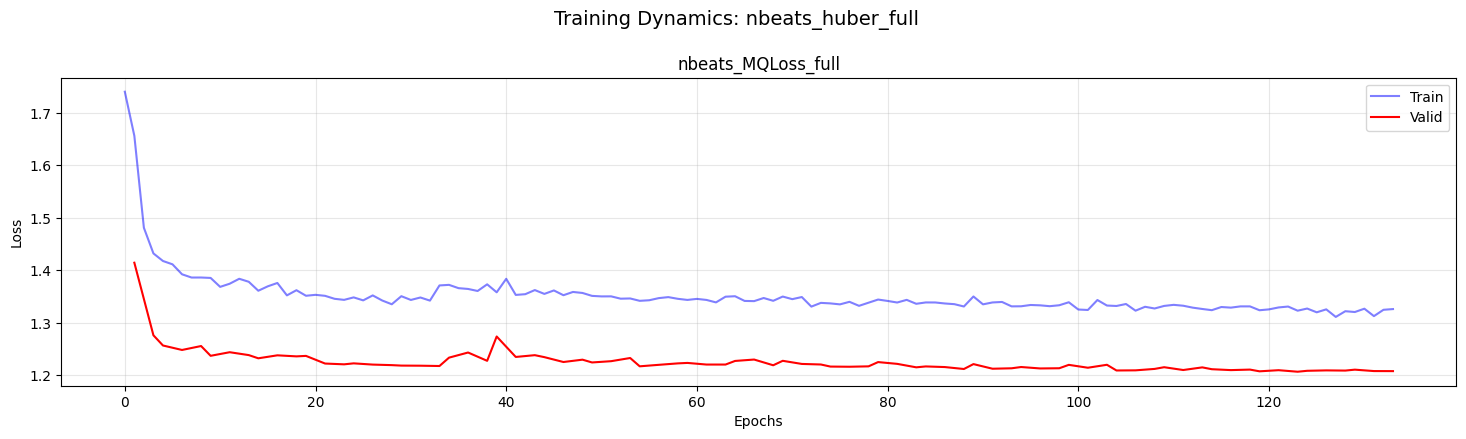

In [65]:
import matplotlib.pyplot as plt

m_df = pd.read_csv("logs/nbeats_mqloss_stable_full/version_0/metrics.csv")
train_m_df = m_df[['epoch', 'train_loss_epoch']].dropna()
valid_m_df = m_df[['epoch', 'valid_loss']].dropna()

plt.figure(figsize=(18, 4))
plt.plot(train_m_df['epoch'], train_m_df['train_loss_epoch'], label='Train', color='blue', alpha=0.5)
plt.plot(valid_m_df['epoch'], valid_m_df['valid_loss'], label='Valid', color='red', linewidth=1.5)

plt.title(f"nbeats_MQLoss_full")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle(f"Training Dynamics: nbeats_huber_full", fontsize=14, y=1.05)
plt.show()

# **3. Model A: Global N-BEATSx (The Challenger)**
- Setup the Global Model (Batch Size 1024).
- Train on full dataset.
- **Result:** Print Global RMSE (~2.36).

# **4. Model B: Global LightGBM (The Control)**
- *Critical Step:* We must train LightGBM on the *same* global data to compare fairly.
- Setup Global LightGBM (feature engineering on 30k items).
- Train (this will take the ~15 mins).
- **Result:** Print Global RMSE (~2.19).

### Loading and preprocessing data

In [36]:
import pandas as pd
import numpy as np
import torch
import lightgbm as lgb
import gc

# ==========================================
# 1. CONFIGURATION (RAM OPTIMIZED)
# ==========================================
TARGET = 'sales'
HORIZON = 28
# We need a buffer to calculate lags. 
# If we want to train from Day 1200, we need Day 1140 loaded to calc lag_60.
START_DAY = 1200 
BUFFER = 60 

print(f"Loading Global M5 Dataset for LightGBM...")

# ==========================================
# 2. DATA LOADING (The RAM Safe Way)
# ==========================================

# A. SALES
print("Loading Sales...")
df_sales = read_and_squeeze('sales_train_evaluation.csv')

# Melt
print("Melting...")
id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
df_lgbm_glob = pd.melt(df_sales, id_vars=id_vars, var_name='d', value_name='sales')
del df_sales; gc.collect()

# Convert d to int
df_lgbm_glob['d_int'] = df_lgbm_glob['d'].apply(lambda x: int(x.split('_')[1]))
# FILTER EARLY: Keep only needed history + buffer
print(f"Filtering history < Day {START_DAY - BUFFER}...")
df_lgbm_glob = df_lgbm_glob[df_lgbm_glob['d_int'] >= (START_DAY - BUFFER)]

# Downcast Sales immediately
df_lgbm_glob['sales'] = df_lgbm_glob['sales'].astype('float32')

# B. CALENDAR
print("Merging Calendar...")
df_cal = read_and_squeeze('calendar.csv')

df_cal['d_int'] = df_cal['d'].apply(lambda x: int(x.split('_')[1]))
# Filter Calendar
df_cal = df_cal[df_cal['d_int'] >= (START_DAY - BUFFER)]
# Select only needed
df_cal = df_cal[['d', 'date', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'wm_yr_wk', 'snap_CA', 'snap_TX', 'snap_WI']]
# Downcast Snaps
cols_int8 = ['snap_CA', 'snap_TX', 'snap_WI']
df_cal[cols_int8] = df_cal[cols_int8].fillna(0).astype('int8')

# Merge
df_lgbm_glob = df_lgbm_glob.merge(df_cal, on='d', how='left')
# df_lgbm_glob = df_lgbm_glob.drop(columns=['d']) # Drop string column
del df_cal; gc.collect()

# C. PRICES
print("Merging Prices...")
df_prices = read_and_squeeze('sell_prices.csv')

df_lgbm_glob = df_lgbm_glob.merge(df_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
del df_prices; gc.collect()

# Fill Prices
df_lgbm_glob['sell_price'] = df_lgbm_glob['sell_price'].astype('float32')
# We do a simplified fill for memory speed (forward fill per group is slow in pandas on 50M rows)
# We will trust LightGBM to handle NaNs, or do a simple fill.
# Let's do a simple global fill to prevent errors, as precise GroupBy fill is RAM heavy.
# Note: For a "Senior" Baseline, accurate filling is better, but RAM is the constraint.
# Let's try the transform. If it crashes, remove this line.
print("Filling Prices (This might be slow)...")
df_lgbm_glob['sell_price'] = df_lgbm_glob.groupby('id')['sell_price'].transform(lambda x: x.ffill().bfill())

Loading Global M5 Dataset for LightGBM...
Loading Sales...
For sales_train_evaluation.csv, mem. usage decreased from 452.91 Mb to 96.13 Mb (78.8% reduction)
Melting...
Filtering history < Day 1140...
Merging Calendar...
For calendar.csv, mem. usage decreased from  0.21 Mb to  0.12 Mb (41.9% reduction)
Merging Prices...
For sell_prices.csv, mem. usage decreased from 208.77 Mb to 130.48 Mb (37.5% reduction)
Filling Prices (This might be slow)...


In [9]:
df_lgbm_glob.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,d_int,date,...,year,event_name_1,event_type_1,event_name_2,event_type_2,wm_yr_wk,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1140,0.0,1140,2014-03-13,...,2014,NaN,NaN,NaN,NaN,11406,0,1,0,8.257812
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1140,0.0,1140,2014-03-13,...,2014,NaN,NaN,NaN,NaN,11406,0,1,0,3.970703
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1140,0.0,1140,2014-03-13,...,2014,NaN,NaN,NaN,NaN,11406,0,1,0,2.970703
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1140,1.0,1140,2014-03-13,...,2014,NaN,NaN,NaN,NaN,11406,0,1,0,4.640625
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1140,0.0,1140,2014-03-13,...,2014,NaN,NaN,NaN,NaN,11406,0,1,0,3.080078


In [7]:
df_calndr = read_and_squeeze('calendar.csv')
display(df_calndr)

For calendar.csv, mem. usage decreased from  0.21 Mb to  0.12 Mb (41.9% reduction)


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0


### Feature engeneering

In [37]:
# ==========================================
# 3. FEATURE ENGINEERING
# ==========================================
print("Engineering Features...")

# 1. Cyclical Encoding for Time Features
# We map the time features onto a circle to preserve continuity.
# e.g., Month 12 (Dec) is close to Month 1 (Jan).

# Weekly Cycle (wday is 1-7)
df_lgbm_glob['wday_sin'] = np.sin(2 * np.pi * df_lgbm_glob['wday'] / 7).astype('float32')
df_lgbm_glob['wday_cos'] = np.cos(2 * np.pi * df_lgbm_glob['wday'] / 7).astype('float32')

# Annual Cycle (month is 1-12)
df_lgbm_glob['month_sin'] = np.sin(2 * np.pi * df_lgbm_glob['month'] / 12).astype('float32')
df_lgbm_glob['month_cos'] = np.cos(2 * np.pi * df_lgbm_glob['month'] / 12).astype('float32')

# Drop the raw integers in ['month', 'wday'] to save memory.
# df_lgbm_glob.drop(columns=['month', 'wday'], inplace=True)

# 2. Fill NaNs in Event Columns (Crucial for M5)
# We treat "NaN" as a "NoEvent" category.
event_cols = ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']
for col in event_cols:
    df_lgbm_glob[col] = df_lgbm_glob[col].astype('object').fillna("NoEvent")

# 3. Encode Categoricals
cat_feats = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'] + event_cols
for col in cat_feats:
    # Now "NoEvent" will be assigned a specific integer code
    df_lgbm_glob[col] = df_lgbm_glob[col].astype('category')

# 4. Dynamic SNAP (Same logic as N-BEATSx for fairness)
conditions = [
    df_lgbm_glob['state_id'] == 'CA',
    df_lgbm_glob['state_id'] == 'TX',
    df_lgbm_glob['state_id'] == 'WI'
]
choices = [df_lgbm_glob['snap_CA'], df_lgbm_glob['snap_TX'], df_lgbm_glob['snap_WI']]
df_lgbm_glob['snap_active'] = np.select(conditions, choices, default=0).astype('int8')

# 5. Lags & Rolling
# We calculate these only where d_int >= START_DAY to save compute, 
# but pandas shift operates on the whole index.
print("Creating Lags...")
lags = [28, 35, 42, 49]
for lag in lags:
    df_lgbm_glob[f'lag_{lag}'] = df_lgbm_glob.groupby('id')['sales'].shift(lag).astype('float32')

print("Creating Rolling Means...")
df_lgbm_glob['rolling_mean_7'] = df_lgbm_glob.groupby('id')['sales'].transform(
    lambda x: x.shift(28).rolling(7).mean()).astype('float32')
df_lgbm_glob['rolling_mean_28'] = df_lgbm_glob.groupby('id')['sales'].transform(
    lambda x: x.shift(28).rolling(28).mean()).astype('float32')

# ==========================================
# 4. TRAINING PREP
# ==========================================
# Now we cut off the buffer. We only wanted it to calculate the lags.
df_lgbm_glob = df_lgbm_glob[df_lgbm_glob['d_int'] >= START_DAY]

# Drop NaNs created by lags
# df_lgbm_glob = df_lgbm_glob.dropna(subset=['rolling_mean_28', 'lag_28']) # I need to drop all lag cols and rolling cols
lag_cols = [f'lag_{lag}' for lag in lags]
rolling_cols = ['rolling_mean_7', 'rolling_mean_28']
df_lgbm_glob = df_lgbm_glob.dropna(subset=lag_cols + rolling_cols)

# Split
max_d = df_lgbm_glob['d_int'].max()
test_start_d = max_d - HORIZON
valid_start_d = test_start_d - HORIZON

train_mask = df_lgbm_glob['d_int'] <= valid_start_d
valid_mask = (df_lgbm_glob['d_int'] > valid_start_d) & (df_lgbm_glob['d_int'] <= test_start_d)
test_mask = df_lgbm_glob['d_int'] > test_start_d
# test_mask_0 = (df_lgbm_glob['d_int'] >= test_start_d) & (df_lgbm_glob['d_int'] < max_d)

# Define features (Drop IDs that aren't features)
drop_cols = ['sales', 'd_int', 'id', 'd', 'date', 'wm_yr_wk', 'month', 'wday', 'snap_CA', 'snap_TX', 'snap_WI']
features = [c for c in df_lgbm_glob.columns if c not in drop_cols]

print(f"Training on {train_mask.sum()} rows. Validating on {valid_mask.sum()} rows.")
print(f"Testing on {test_mask.sum()} rows. Testing on {test_mask.sum()} rows.")
print(f"Features: {features}")

# Create LGB Datasets
# free_raw_data=True helps free up pandas memory after loading into LGB
train_data = lgb.Dataset(
    df_lgbm_glob[train_mask][features], 
    label=df_lgbm_glob[train_mask]['sales'], 
    categorical_feature=cat_feats,
    free_raw_data=True
)
valid_data = lgb.Dataset(
    df_lgbm_glob[valid_mask][features], 
    label=df_lgbm_glob[valid_mask]['sales'], 
    reference=train_data,
    free_raw_data=True
)

# Clean up Pandas to free RAM for LightGBM Training
# del df; gc.collect()

Engineering Features...
Creating Lags...
Creating Rolling Means...
Training on 20916140 rows. Validating on 853720 rows.
Testing on 853720 rows. Testing on 853720 rows.
Features: ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'sell_price', 'wday_sin', 'wday_cos', 'month_sin', 'month_cos', 'snap_active', 'lag_28', 'lag_35', 'lag_42', 'lag_49', 'rolling_mean_7', 'rolling_mean_28']


### Training

In [69]:
import optuna
from optuna.integration import LightGBMPruningCallback

print("Starting Hyperparameter Tuning with Optuna...")

# 1. Create a smaller dataset for tuning to save time (e.g., 10% subsample)
# We use a random sample to preserve the distribution
df_tune = df_lgbm_glob[train_mask].sample(frac=0.1, random_state=42)
tune_data = lgb.Dataset(
    df_tune[features], 
    label=df_tune['sales'], 
    categorical_feature=cat_feats,
    free_raw_data=False
)

# 2. Define the Objective Function
def objective(trial):
    # Search Space
    param_grid = {
        'objective': 'tweedie',
        'metric': 'rmse',
        'tweedie_variance_power': trial.suggest_float('tweedie_variance_power', 1.0, 1.5),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 0.9),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 0.9),
        'bagging_freq': 1,
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'n_jobs': -1,
        'seed': 42,
        'verbose': -1
    }

    # Train with pruning (stops bad trials early)
    cv_results = lgb.cv(
        param_grid,
        tune_data,
        num_boost_round=500,
        nfold=3,
        stratified=False,
        callbacks=[
            LightGBMPruningCallback(trial, "rmse")
        ]
    )
    
    # Return the best RMSE from Cross Validation
    return cv_results['valid rmse-mean'][-1]

# 3. Run Optimization
study = optuna.create_study(direction='minimize', study_name="M5_LGBM")
study.optimize(objective, n_trials=15) # 15 trials is enough to show "seriousness"

print("Best Parameters found:")
print(study.best_params)

Starting Hyperparameter Tuning with Optuna...


[I 2025-12-31 16:48:24,625] A new study created in memory with name: M5_LGBM
[I 2025-12-31 16:50:36,984] Trial 0 finished with value: 2.208436018915774 and parameters: {'tweedie_variance_power': 1.2247695443940267, 'learning_rate': 0.08129962634445509, 'num_leaves': 157, 'feature_fraction': 0.5366699884391756, 'bagging_fraction': 0.644131037698241, 'lambda_l1': 0.848036575003931, 'lambda_l2': 0.27524968618164447}. Best is trial 0 with value: 2.208436018915774.
[I 2025-12-31 16:53:28,126] Trial 1 finished with value: 2.1938354645518934 and parameters: {'tweedie_variance_power': 1.192058924434118, 'learning_rate': 0.0596355235806575, 'num_leaves': 288, 'feature_fraction': 0.721880071236087, 'bagging_fraction': 0.7074332584863543, 'lambda_l1': 3.0849135705701906e-07, 'lambda_l2': 1.7466361155653143e-07}. Best is trial 1 with value: 2.1938354645518934.
[I 2025-12-31 16:55:25,376] Trial 2 finished with value: 2.2078445565238263 and parameters: {'tweedie_variance_power': 1.3494286118235574, 

Best Parameters found:
{'tweedie_variance_power': 1.192058924434118, 'learning_rate': 0.0596355235806575, 'num_leaves': 288, 'feature_fraction': 0.721880071236087, 'bagging_fraction': 0.7074332584863543, 'lambda_l1': 3.0849135705701906e-07, 'lambda_l2': 1.7466361155653143e-07}


In [70]:
# ==========================================
# 5. TRAINING (optimized)
# ==========================================
print("Training Global LightGBM with Optimized Parameters...")

# Start with the best params from Optuna
params = study.best_params

# Add the static parameters that we didn't tune
params['objective'] = 'tweedie'
params['metric'] = 'rmse'
params['n_jobs'] = -1
params['seed'] = 42
params['bin_construct_sample_cnt'] = 200000 

# Train the final model on the FULL dataset
model = lgb.train(
    params,
    train_data,
    num_boost_round=1500, 
    valid_sets=[train_data, valid_data],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(50)]
)

Training Global LightGBM with Optimized Parameters...
Training until validation scores don't improve for 100 rounds
[50]	training's rmse: 2.24998	valid_1's rmse: 2.17517
[100]	training's rmse: 2.15298	valid_1's rmse: 2.13133
[150]	training's rmse: 2.10653	valid_1's rmse: 2.12476
[200]	training's rmse: 2.07745	valid_1's rmse: 2.12206
[250]	training's rmse: 2.05391	valid_1's rmse: 2.1195
[300]	training's rmse: 2.03005	valid_1's rmse: 2.1184
[350]	training's rmse: 2.00798	valid_1's rmse: 2.11828
[400]	training's rmse: 1.99341	valid_1's rmse: 2.11577
[450]	training's rmse: 1.97952	valid_1's rmse: 2.11733
[500]	training's rmse: 1.96831	valid_1's rmse: 2.11688
Early stopping, best iteration is:
[403]	training's rmse: 1.99211	valid_1's rmse: 2.11546


### Results and saving the model

In [71]:
# ==========================================
# 6. RESULTS
# ==========================================
print("Global LightGBM Finished.")
print(f"Best validation RMSE: {model.best_score['valid_1']['rmse']:.4f}")

# Save Model
model.save_model('lgbm_global_model.txt')

Global LightGBM Finished.
Best validation RMSE: 2.1155


In [38]:
loaded_model = lgb.Booster(model_file='lgbm_global_model.txt')

### compute predictions

In [39]:
lgbm_preds = loaded_model.predict(df_lgbm_glob[test_mask][features])

In [40]:
df_lgbm_glob_preds = df_lgbm_glob[test_mask][['id', 'd', 'date', 'sales']].copy()
print("df_lgbm_glob_preds = df_lgbm_glob[test_mask][['id', 'd', 'date', 'sales']].copy()")
# display(df_lgbm_glob_preds)

df_lgbm_glob_preds = df_lgbm_glob_preds.rename(columns={'id': 'unique_id', 'date': 'ds'})
print("df_lgbm_glob_preds = df_lgbm_glob_preds.rename(columns={'id': 'unique_id', 'date': 'ds'})")
# display(df_lgbm_glob_preds)

df_lgbm_glob_preds = df_lgbm_glob_preds.rename(columns={'sales': 'y'})
print("df_lgbm_glob_preds = df_lgbm_glob_preds.rename(columns={'sales': 'y'})")
# display(df_lgbm_glob_preds)

df_lgbm_glob_preds['lgbm_pred'] = lgbm_preds
print("df_lgbm_glob_preds['lgbm_pred'] = lgbm_preds")
# display(df_lgbm_glob_preds)

df_lgbm_glob_preds['ds'] = pd.to_datetime(df_lgbm_glob_preds['ds'])

print("df_lgbm_glob_preds.info()")
df_lgbm_glob_preds.info()

df_lgbm_glob_preds = df_lgbm_glob[test_mask][['id', 'd', 'date', 'sales']].copy()
df_lgbm_glob_preds = df_lgbm_glob_preds.rename(columns={'id': 'unique_id', 'date': 'ds'})
df_lgbm_glob_preds = df_lgbm_glob_preds.rename(columns={'sales': 'y'})
df_lgbm_glob_preds['lgbm_pred'] = lgbm_preds
df_lgbm_glob_preds.info()
<class 'pandas.core.frame.DataFrame'>
Index: 853720 entries, 23599260 to 24452979
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   unique_id  853720 non-null  object        
 1   d          853720 non-null  object        
 2   ds         853720 non-null  datetime64[ns]
 3   y          853720 non-null  float32       
 4   lgbm_pred  853720 non-null  float64       
dtypes: datetime64[ns](1), float32(1), float64(1), object(2)
memory usage: 35.8+ MB


In [41]:
lgbm_rmse_full = np.sqrt(np.mean((df_lgbm_glob_preds['y'] - df_lgbm_glob_preds['lgbm_pred']) ** 2))
print("="*40)
print(f"TEST DATASET Global LightGBM RMSE: {lgbm_rmse_full:.4f}")
print("="*40)

TEST DATASET Global LightGBM RMSE: 2.1986


In [35]:
df_lgbm_glob_preds

,unique_id,d,ds,y,lgbm_pred
23599260,HOBBIES_1_001_CA_1_evaluation,d_1914,2016-04-25,0.0,0.672835
23599261,HOBBIES_1_002_CA_1_evaluation,d_1914,2016-04-25,0.0,0.280617
23599262,HOBBIES_1_003_CA_1_evaluation,d_1914,2016-04-25,0.0,0.321648
23599263,HOBBIES_1_004_CA_1_evaluation,d_1914,2016-04-25,0.0,1.993628
23599264,HOBBIES_1_005_CA_1_evaluation,d_1914,2016-04-25,1.0,1.017023
...,...,...,...,...,...
24452975,FOODS_3_823_WI_3_evaluation,d_1941,2016-05-22,1.0,0.346197
24452976,FOODS_3_824_WI_3_evaluation,d_1941,2016-05-22,0.0,0.096476
24452977,FOODS_3_825_WI_3_evaluation,d_1941,2016-05-22,2.0,0.881766
24452978,FOODS_3_826_WI_3_evaluation,d_1941,2016-05-22,0.0,1.081411


### Old code that should be deleted`

In [43]:
results_mqloss_lgbm_full = results_mqloss_stable_full.merge(df_lgbm_glob_preds[['unique_id', 'ds', 'lgbm_pred']], on=['unique_id', 'ds'], how='left')
display(results_mqloss_lgbm_full)

,unique_id,ds,NBEATSx_MQLoss_Stable-median,NBEATSx_MQLoss_Stable-hi-60.0,NBEATSx_MQLoss_Stable-hi-80.0,y,lgbm_pred
0,FOODS_1_001_CA_1_evaluation,2016-04-25,0.004941,1.427917,2.284245,2,0.678023
1,FOODS_1_001_CA_1_evaluation,2016-04-26,-0.004922,1.395466,2.214075,0,0.641705
2,FOODS_1_001_CA_1_evaluation,2016-04-27,0.000058,1.399013,2.232355,0,0.679327
3,FOODS_1_001_CA_1_evaluation,2016-04-28,0.011217,1.426816,2.280685,0,0.685231
4,FOODS_1_001_CA_1_evaluation,2016-04-29,0.067805,1.554290,2.482586,0,0.913752
...,...,...,...,...,...,...,...
853715,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,-0.000055,0.000202,0.032146,0,0.052311
853716,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,-0.000002,0.000343,0.032764,0,0.054777
853717,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,-0.000055,0.000275,0.039893,0,0.064878
853718,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,-0.000120,0.000207,0.043745,0,0.082123


In [44]:
lgbm_rmse_full = np.sqrt(np.mean((results_mqloss_lgbm_full['y'] - results_mqloss_lgbm_full['lgbm_pred']) ** 2))
mqls_rmse_full = np.sqrt(np.mean((results_mqloss_lgbm_full['y'] - results_mqloss_lgbm_full['NBEATSx_MQLoss_Stable-median']) ** 2))
print("="*40)
print(f"TEST DATASET Global LightGBM RMSE: {lgbm_rmse_full:.4f}")
print("="*40)
print(f"TEST DATASET Global NBEATSx RMSE: {mqls_rmse_full:.4f}")
print("="*40)

TEST DATASET Global LightGBM RMSE: 2.1986
TEST DATASET Global NBEATSx RMSE: 2.1814


In [45]:
results_mqloss_lgbm_all = results_mqloss_lgbm_full.copy()
display(results_mqloss_lgbm_all)

,unique_id,ds,NBEATSx_MQLoss_Stable-median,NBEATSx_MQLoss_Stable-hi-60.0,NBEATSx_MQLoss_Stable-hi-80.0,y,lgbm_pred
0,FOODS_1_001_CA_1_evaluation,2016-04-25,0.004941,1.427917,2.284245,2,0.678023
1,FOODS_1_001_CA_1_evaluation,2016-04-26,-0.004922,1.395466,2.214075,0,0.641705
2,FOODS_1_001_CA_1_evaluation,2016-04-27,0.000058,1.399013,2.232355,0,0.679327
3,FOODS_1_001_CA_1_evaluation,2016-04-28,0.011217,1.426816,2.280685,0,0.685231
4,FOODS_1_001_CA_1_evaluation,2016-04-29,0.067805,1.554290,2.482586,0,0.913752
...,...,...,...,...,...,...,...
853715,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,-0.000055,0.000202,0.032146,0,0.052311
853716,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,-0.000002,0.000343,0.032764,0,0.054777
853717,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,-0.000055,0.000275,0.039893,0,0.064878
853718,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,-0.000120,0.000207,0.043745,0,0.082123


In [ ]:
# Sort train_df just in case
train_df_metric = m5_df.sort_values(['unique_id', 'ds'])
display(m5_df)

# drop rows where sell_price_m5 is -5
train_df_metric = train_df_metric[train_df_metric['sell_price_m5'] != -3]

# drop column 'is_available_check' and 'sell_price_m5' from train_df_metric
train_df_metric = train_df_metric.drop(columns=['is_available_check', 'sell_price_m5', 'is_available'])

# drop the last 28 days from train_df_metric
max_d_int = train_df_metric['d_int'].max()
train_df_metric = train_df_metric[train_df_metric['d_int'] <= (max_d_int - 28)] 

display(train_df_metric)


,unique_id,ds,y,sell_price,is_available,d_int,sell_price_m5,is_available_check
0,FOODS_1_001_CA_1_evaluation,2011-01-29,3,2.000000,1,1,2.000000,1
1,FOODS_1_001_CA_1_evaluation,2011-01-30,0,2.000000,1,2,2.000000,1
2,FOODS_1_001_CA_1_evaluation,2011-01-31,0,2.000000,1,3,2.000000,1
3,FOODS_1_001_CA_1_evaluation,2011-02-01,1,2.000000,1,4,2.000000,1
4,FOODS_1_001_CA_1_evaluation,2011-02-02,4,2.000000,1,5,2.000000,1
...,...,...,...,...,...,...,...,...
59181085,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,0,5.941406,1,1937,5.941406,1
59181086,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,0,5.941406,1,1938,5.941406,1
59181087,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,0,5.941406,1,1939,5.941406,1
59181088,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,0,5.941406,1,1940,5.941406,1


,unique_id,ds,y,sell_price,d_int
0,FOODS_1_001_CA_1_evaluation,2011-01-29,3,2.000000,1
1,FOODS_1_001_CA_1_evaluation,2011-01-30,0,2.000000,2
2,FOODS_1_001_CA_1_evaluation,2011-01-31,0,2.000000,3
3,FOODS_1_001_CA_1_evaluation,2011-02-01,1,2.000000,4
4,FOODS_1_001_CA_1_evaluation,2011-02-02,4,2.000000,5
...,...,...,...,...,...
59181057,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-20,0,5.941406,1909
59181058,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-21,0,5.941406,1910
59181059,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-22,0,5.941406,1911
59181060,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-23,0,5.941406,1912


In [56]:

# Calculate diff squared for naive forecast (y_t - y_{t-1})^2
train_df_metric['diff_sq'] = train_df_metric.groupby('unique_id')['y'].diff().pow(2)
display(train_df_metric)

,unique_id,ds,y,sell_price,d_int,diff_sq
0,FOODS_1_001_CA_1_evaluation,2011-01-29,3,2.000000,1,NaN
1,FOODS_1_001_CA_1_evaluation,2011-01-30,0,2.000000,2,9.0
2,FOODS_1_001_CA_1_evaluation,2011-01-31,0,2.000000,3,0.0
3,FOODS_1_001_CA_1_evaluation,2011-02-01,1,2.000000,4,1.0
4,FOODS_1_001_CA_1_evaluation,2011-02-02,4,2.000000,5,9.0
...,...,...,...,...,...,...
59181057,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-20,0,5.941406,1909,0.0
59181058,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-21,0,5.941406,1910,0.0
59181059,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-22,0,5.941406,1911,0.0
59181060,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-23,0,5.941406,1912,0.0


In [57]:
scaling_factors = train_df_metric.groupby('unique_id')['diff_sq'].mean().pow(0.5)
scaling_factors.min()

0.15844432

In [58]:
# B. Calculate Dollar Weights
# Weight = Sum of (Sales * Price) in the last 28 days of Training
# We need to merge prices back to train_df if not present
# (In our previous script, train_df has 'sell_price')
last_28_days_train = train_df_metric[train_df_metric['ds'] >= (train_df_metric['ds'].max() - pd.Timedelta(days=28))]
display(last_28_days_train)

,unique_id,ds,y,sell_price,d_int,diff_sq
1884,FOODS_1_001_CA_1_evaluation,2016-03-27,0,2.240234,1885,1.0
1885,FOODS_1_001_CA_1_evaluation,2016-03-28,2,2.240234,1886,4.0
1886,FOODS_1_001_CA_1_evaluation,2016-03-29,1,2.240234,1887,1.0
1887,FOODS_1_001_CA_1_evaluation,2016-03-30,1,2.240234,1888,0.0
1888,FOODS_1_001_CA_1_evaluation,2016-03-31,0,2.240234,1889,1.0
...,...,...,...,...,...,...
59181057,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-20,0,5.941406,1909,0.0
59181058,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-21,0,5.941406,1910,0.0
59181059,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-22,0,5.941406,1911,0.0
59181060,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-23,0,5.941406,1912,0.0


In [59]:
last_28_days_train['revenue'] = last_28_days_train['y'] * last_28_days_train['sell_price']
display(last_28_days_train)

/var/folders/c5/09trk0mj389dhs59ptvs9f8h0000gn/T/ipykernel_14260/3871258678.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_28_days_train['revenue'] = last_28_days_train['y'] * last_28_days_train['sell_price']


,unique_id,ds,y,sell_price,d_int,diff_sq,revenue
1884,FOODS_1_001_CA_1_evaluation,2016-03-27,0,2.240234,1885,1.0,0.000000
1885,FOODS_1_001_CA_1_evaluation,2016-03-28,2,2.240234,1886,4.0,4.480469
1886,FOODS_1_001_CA_1_evaluation,2016-03-29,1,2.240234,1887,1.0,2.240234
1887,FOODS_1_001_CA_1_evaluation,2016-03-30,1,2.240234,1888,0.0,2.240234
1888,FOODS_1_001_CA_1_evaluation,2016-03-31,0,2.240234,1889,1.0,0.000000
...,...,...,...,...,...,...,...
59181057,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-20,0,5.941406,1909,0.0,0.000000
59181058,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-21,0,5.941406,1910,0.0,0.000000
59181059,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-22,0,5.941406,1911,0.0,0.000000
59181060,HOUSEHOLD_2_516_WI_3_evaluation,2016-04-23,0,5.941406,1912,0.0,0.000000


In [60]:
total_revenue = last_28_days_train['revenue'].sum()
display(total_revenue)

3891429.8

In [61]:
item_revenue = last_28_days_train.groupby('unique_id')['revenue'].sum()
display(item_revenue)

unique_id
FOODS_1_001_CA_1_evaluation        73.927734
FOODS_1_001_CA_2_evaluation        71.687500
FOODS_1_001_CA_3_evaluation        53.765625
FOODS_1_001_CA_4_evaluation        20.162109
FOODS_1_001_TX_1_evaluation         2.240234
                                     ...    
HOUSEHOLD_2_516_TX_2_evaluation    53.472656
HOUSEHOLD_2_516_TX_3_evaluation    29.707031
HOUSEHOLD_2_516_WI_1_evaluation     5.941406
HOUSEHOLD_2_516_WI_2_evaluation     5.941406
HOUSEHOLD_2_516_WI_3_evaluation     0.000000
Name: revenue, Length: 30490, dtype: float32

In [62]:
weights = item_revenue / total_revenue
display(weights)

unique_id
FOODS_1_001_CA_1_evaluation        1.899758e-05
FOODS_1_001_CA_2_evaluation        1.842189e-05
FOODS_1_001_CA_3_evaluation        1.381642e-05
FOODS_1_001_CA_4_evaluation        5.181157e-06
FOODS_1_001_TX_1_evaluation        5.756841e-07
                                       ...     
HOUSEHOLD_2_516_TX_2_evaluation    1.374113e-05
HOUSEHOLD_2_516_TX_3_evaluation    7.633963e-06
HOUSEHOLD_2_516_WI_1_evaluation    1.526793e-06
HOUSEHOLD_2_516_WI_2_evaluation    1.526793e-06
HOUSEHOLD_2_516_WI_3_evaluation    0.000000e+00
Name: revenue, Length: 30490, dtype: float32

In [63]:
# C. Calculate RMSSE for our Models
# RMSSE = RMSE / ScalingFactor
score_df = results_mqloss_lgbm_all.copy()
score_df['sq_err_nbeats'] = (score_df['y'] - score_df['NBEATSx_MQLoss_Stable-median'])**2
score_df['sq_err_lgbm'] = (score_df['y'] - score_df['lgbm_pred'])**2
display(score_df)

,unique_id,ds,NBEATSx_MQLoss_Stable-median,NBEATSx_MQLoss_Stable-hi-60.0,NBEATSx_MQLoss_Stable-hi-80.0,y,lgbm_pred,sq_err_nbeats,sq_err_lgbm
0,FOODS_1_001_CA_1_evaluation,2016-04-25,0.004941,1.427917,2.284245,2,0.678023,3.980259e+00,1.747622
1,FOODS_1_001_CA_1_evaluation,2016-04-26,-0.004922,1.395466,2.214075,0,0.641705,2.422232e-05,0.411785
2,FOODS_1_001_CA_1_evaluation,2016-04-27,0.000058,1.399013,2.232355,0,0.679327,3.385411e-09,0.461486
3,FOODS_1_001_CA_1_evaluation,2016-04-28,0.011217,1.426816,2.280685,0,0.685231,1.258099e-04,0.469542
4,FOODS_1_001_CA_1_evaluation,2016-04-29,0.067805,1.554290,2.482586,0,0.913752,4.597519e-03,0.834942
...,...,...,...,...,...,...,...,...,...
853715,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,-0.000055,0.000202,0.032146,0,0.052311,3.060633e-09,0.002736
853716,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,-0.000002,0.000343,0.032764,0,0.054777,4.093795e-12,0.003001
853717,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,-0.000055,0.000275,0.039893,0,0.064878,3.070864e-09,0.004209
853718,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,-0.000120,0.000207,0.043745,0,0.082123,1.442117e-08,0.006744


In [64]:
# MSE per item
mse_nbeats = score_df.groupby('unique_id')['sq_err_nbeats'].mean()
mse_lgbm = score_df.groupby('unique_id')['sq_err_lgbm'].mean()
display(mse_nbeats)
display(mse_lgbm)

unique_id
FOODS_1_001_CA_1_evaluation        2.423854
FOODS_1_001_CA_2_evaluation        1.097978
FOODS_1_001_CA_3_evaluation        3.463545
FOODS_1_001_CA_4_evaluation        0.187644
FOODS_1_001_TX_1_evaluation        1.928750
                                     ...   
HOUSEHOLD_2_516_TX_2_evaluation    0.142831
HOUSEHOLD_2_516_TX_3_evaluation    0.392872
HOUSEHOLD_2_516_WI_1_evaluation    0.250002
HOUSEHOLD_2_516_WI_2_evaluation    0.071431
HOUSEHOLD_2_516_WI_3_evaluation    0.071429
Name: sq_err_nbeats, Length: 30490, dtype: float32

unique_id
FOODS_1_001_CA_1_evaluation        1.845833
FOODS_1_001_CA_2_evaluation        1.097984
FOODS_1_001_CA_3_evaluation        2.534726
FOODS_1_001_CA_4_evaluation        0.220062
FOODS_1_001_TX_1_evaluation        1.470216
                                     ...   
HOUSEHOLD_2_516_TX_2_evaluation    0.144467
HOUSEHOLD_2_516_TX_3_evaluation    0.291904
HOUSEHOLD_2_516_WI_1_evaluation    0.224032
HOUSEHOLD_2_516_WI_2_evaluation    0.067354
HOUSEHOLD_2_516_WI_3_evaluation    0.064294
Name: sq_err_lgbm, Length: 30490, dtype: float64

In [65]:
# RMSE per item
rmse_nbeats_series = mse_nbeats.pow(0.5)
rmse_lgbm_series = mse_lgbm.pow(0.5)
display(rmse_nbeats_series)
display(rmse_lgbm_series)

unique_id
FOODS_1_001_CA_1_evaluation        1.556873
FOODS_1_001_CA_2_evaluation        1.047844
FOODS_1_001_CA_3_evaluation        1.861060
FOODS_1_001_CA_4_evaluation        0.433180
FOODS_1_001_TX_1_evaluation        1.388795
                                     ...   
HOUSEHOLD_2_516_TX_2_evaluation    0.377930
HOUSEHOLD_2_516_TX_3_evaluation    0.626795
HOUSEHOLD_2_516_WI_1_evaluation    0.500002
HOUSEHOLD_2_516_WI_2_evaluation    0.267265
HOUSEHOLD_2_516_WI_3_evaluation    0.267262
Name: sq_err_nbeats, Length: 30490, dtype: float32

unique_id
FOODS_1_001_CA_1_evaluation        1.358614
FOODS_1_001_CA_2_evaluation        1.047847
FOODS_1_001_CA_3_evaluation        1.592082
FOODS_1_001_CA_4_evaluation        0.469107
FOODS_1_001_TX_1_evaluation        1.212524
                                     ...   
HOUSEHOLD_2_516_TX_2_evaluation    0.380088
HOUSEHOLD_2_516_TX_3_evaluation    0.540282
HOUSEHOLD_2_516_WI_1_evaluation    0.473320
HOUSEHOLD_2_516_WI_2_evaluation    0.259526
HOUSEHOLD_2_516_WI_3_evaluation    0.253563
Name: sq_err_lgbm, Length: 30490, dtype: float64

In [68]:
# RMSSE (Scaled Error)
rmsse_nbeats = rmse_nbeats_series / scaling_factors
rmsse_lgbm = rmse_lgbm_series / scaling_factors
display(rmsse_nbeats)
display(rmsse_lgbm)

unique_id
FOODS_1_001_CA_1_evaluation        0.910768
FOODS_1_001_CA_2_evaluation        0.437339
FOODS_1_001_CA_3_evaluation        0.582771
FOODS_1_001_CA_4_evaluation        0.429048
FOODS_1_001_TX_1_evaluation        0.746593
                                     ...   
HOUSEHOLD_2_516_TX_2_evaluation    0.480263
HOUSEHOLD_2_516_TX_3_evaluation    1.324792
HOUSEHOLD_2_516_WI_1_evaluation    1.207199
HOUSEHOLD_2_516_WI_2_evaluation    1.007831
HOUSEHOLD_2_516_WI_3_evaluation    0.503838
Length: 30490, dtype: float32

unique_id
FOODS_1_001_CA_1_evaluation        0.794787
FOODS_1_001_CA_2_evaluation        0.437341
FOODS_1_001_CA_3_evaluation        0.498544
FOODS_1_001_CA_4_evaluation        0.464633
FOODS_1_001_TX_1_evaluation        0.651834
                                     ...   
HOUSEHOLD_2_516_TX_2_evaluation    0.483005
HOUSEHOLD_2_516_TX_3_evaluation    1.141938
HOUSEHOLD_2_516_WI_1_evaluation    1.142779
HOUSEHOLD_2_516_WI_2_evaluation    0.978646
HOUSEHOLD_2_516_WI_3_evaluation    0.478012
Length: 30490, dtype: float64

In [69]:
# D. Weighted RMSSE
wrmsse_nbeats = (rmsse_nbeats * weights).sum()
wrmsse_lgbm = (rmsse_lgbm * weights).sum()

In [70]:
print(f"\nWRMSSE (Item-Level):")
print(f"N-BEATSx:  {wrmsse_nbeats:.4f}")
print(f"LightGBM:  {wrmsse_lgbm:.4f}")


WRMSSE (Item-Level):
N-BEATSx:  0.8558
LightGBM:  0.8560


In [73]:
display(total_revenue)
display(total_revenue*(wrmsse_lgbm-wrmsse_nbeats))

3891429.8

1035.7621144994305

In [71]:
# ==========================================
# 4. FINAL VERDICT
# ==========================================
print("-" * 30)
winner = "LightGBM" if wrmsse_lgbm < wrmsse_nbeats else "N-BEATSx"
print(f"WINNER: {winner}")
print("-" * 30)

------------------------------
WINNER: N-BEATSx
------------------------------


### New code for computing WRMSSE

In [12]:
m5_df

,unique_id,ds,y,sell_price,is_available,snap_active,is_event,d_int
0,FOODS_1_001_CA_1_evaluation,2011-01-29,3,2.000000,1,0,0,1
1,FOODS_1_001_CA_1_evaluation,2011-01-30,0,2.000000,1,0,0,2
2,FOODS_1_001_CA_1_evaluation,2011-01-31,0,2.000000,1,0,0,3
3,FOODS_1_001_CA_1_evaluation,2011-02-01,1,2.000000,1,1,0,4
4,FOODS_1_001_CA_1_evaluation,2011-02-02,4,2.000000,1,1,0,5
...,...,...,...,...,...,...,...,...
59181085,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,0,5.941406,1,0,0,1937
59181086,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,0,5.941406,1,0,0,1938
59181087,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,0,5.941406,1,0,0,1939
59181088,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,0,5.941406,1,0,0,1940


In [6]:
df_calndr = read_and_squeeze('calendar.csv')
# display(df_calndr)
df_eval = read_and_squeeze('sales_train_evaluation.csv')
# display(df_eval)
df_prices = read_and_squeeze('sell_prices.csv')
# display(df_prices)

# add new columns to m5_df
# "store_id" and "item_id" from df_eval
m5_df = m5_df.merge(df_eval[['id', 'store_id', 'item_id']], left_on='unique_id', right_on='id', how='left')
m5_df = m5_df.drop(columns=['id'])
# m5_df

# convert 'date' in df_calndr to datetime
df_calndr['date'] = pd.to_datetime(df_calndr['date'])

# add new columns to m5_df
# "wm_yr_wk" from df_calndr
m5_df = m5_df.merge(df_calndr[['date', 'wm_yr_wk']], left_on='ds', right_on='date', how='left')
m5_df = m5_df.drop(columns=['date'])
# m5_df

# add new columns to m5_df
# 'sell_price' from df_prices
df_prices = df_prices.rename(columns={'sell_price': 'sell_price_m5'})
m5_df = m5_df.merge(df_prices, left_on=['store_id', 'item_id', 'wm_yr_wk'], right_on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
# m5_df

# drop unnecessary columns to save memory
m5_df = m5_df.drop(columns=['snap_active', 'is_event', 'store_id', 'item_id', 'wm_yr_wk'])

print(f" --- m5_df --- ")
print(f"Final Dataset Shape: {m5_df.shape}")
print(f"Memory Usage: {m5_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

m5_df

For calendar.csv, mem. usage decreased from  0.21 Mb to  0.12 Mb (41.9% reduction)
For sales_train_evaluation.csv, mem. usage decreased from 452.91 Mb to 96.13 Mb (78.8% reduction)
For sell_prices.csv, mem. usage decreased from 208.77 Mb to 130.48 Mb (37.5% reduction)
 --- m5_df --- 
Final Dataset Shape: (59181090, 7)
Memory Usage: 6.55 GB


,unique_id,ds,y,sell_price,is_available,d_int,sell_price_m5
0,FOODS_1_001_CA_1_evaluation,2011-01-29,3,2.000000,1,1,2.000000
1,FOODS_1_001_CA_1_evaluation,2011-01-30,0,2.000000,1,2,2.000000
2,FOODS_1_001_CA_1_evaluation,2011-01-31,0,2.000000,1,3,2.000000
3,FOODS_1_001_CA_1_evaluation,2011-02-01,1,2.000000,1,4,2.000000
4,FOODS_1_001_CA_1_evaluation,2011-02-02,4,2.000000,1,5,2.000000
...,...,...,...,...,...,...,...
59181085,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-18,0,5.941406,1,1937,5.941406
59181086,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-19,0,5.941406,1,1938,5.941406
59181087,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-20,0,5.941406,1,1939,5.941406
59181088,HOUSEHOLD_2_516_WI_3_evaluation,2016-05-21,0,5.941406,1,1940,5.941406


In [8]:
#  fill NaN sell_price_m5 with -3
m5_df['sell_price_m5'] = m5_df['sell_price_m5'].fillna(-3)

# check that 'is_available' is 0 when 'sell_price_m5' is -3 and 1 otherwise
m5_df['is_available_check'] = np.where(m5_df['sell_price_m5'] == -3, 0, 1)
availability_mismatch = m5_df[m5_df['is_available'] != m5_df['is_available_check']]
print(f"Number of availability mismatches: {len(availability_mismatch)}")

Number of availability mismatches: 0


In [14]:
# Chech the availablity of each unique_id
# I want to know for each item, how many times the 'is_available' state changes
# I want to calculate the number of state changes for each unique_id
# I want to order the results by the number of state changes in descending order
availability_changes = m5_df.groupby('unique_id')['is_available'].apply(lambda x: (x != x.shift()).sum() - 1).reset_index(name='num_state_changes')
availability_changes = availability_changes.sort_values(by='num_state_changes', ascending=False)
display(availability_changes)


,unique_id,num_state_changes
15245,HOBBIES_1_090_TX_2_evaluation,1
14660,HOBBIES_1_030_CA_1_evaluation,1
14658,HOBBIES_1_029_WI_2_evaluation,1
24934,HOUSEHOLD_1_501_TX_1_evaluation,1
24935,HOUSEHOLD_1_501_TX_2_evaluation,1
...,...,...
14096,FOODS_3_800_TX_3_evaluation,0
14097,FOODS_3_800_WI_1_evaluation,0
14099,FOODS_3_800_WI_3_evaluation,0
14130,FOODS_3_804_CA_1_evaluation,0


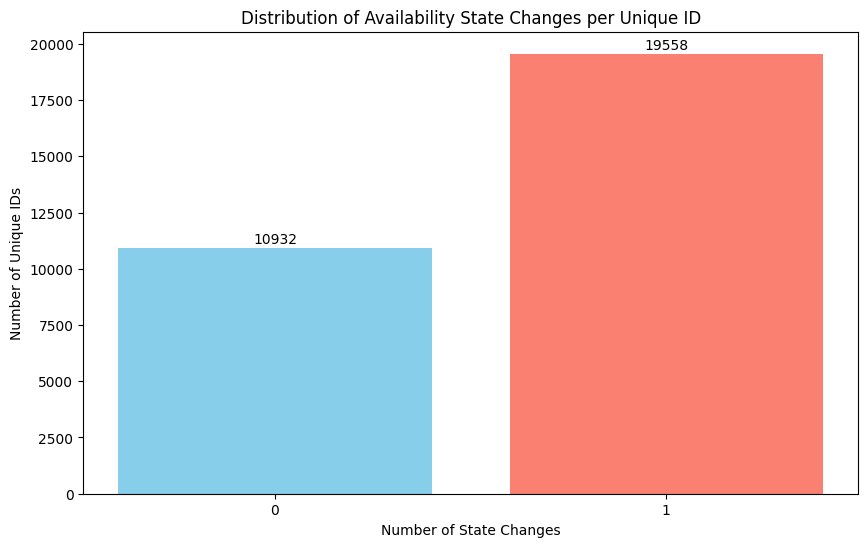

In [18]:
# Plot the number of state changes
# I want to see a figure that shows that the number of unique_id and 0 changes + the number of unique_id with 1 change = total unique_id
# I want to show the number of unique_id on each bar. The two numbers should add up to 30490 unique_id
import matplotlib.pyplot as plt
change_counts = availability_changes['num_state_changes'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
plt.bar(change_counts.index.astype(str), change_counts.values, color=['skyblue', 'salmon'])
plt.xlabel('Number of State Changes')
plt.ylabel('Number of Unique IDs')
plt.title('Distribution of Availability State Changes per Unique ID')
for i, v in enumerate(change_counts.values):
    plt.text(i, v + 50, str(v), ha='center', va='bottom')
plt.show()


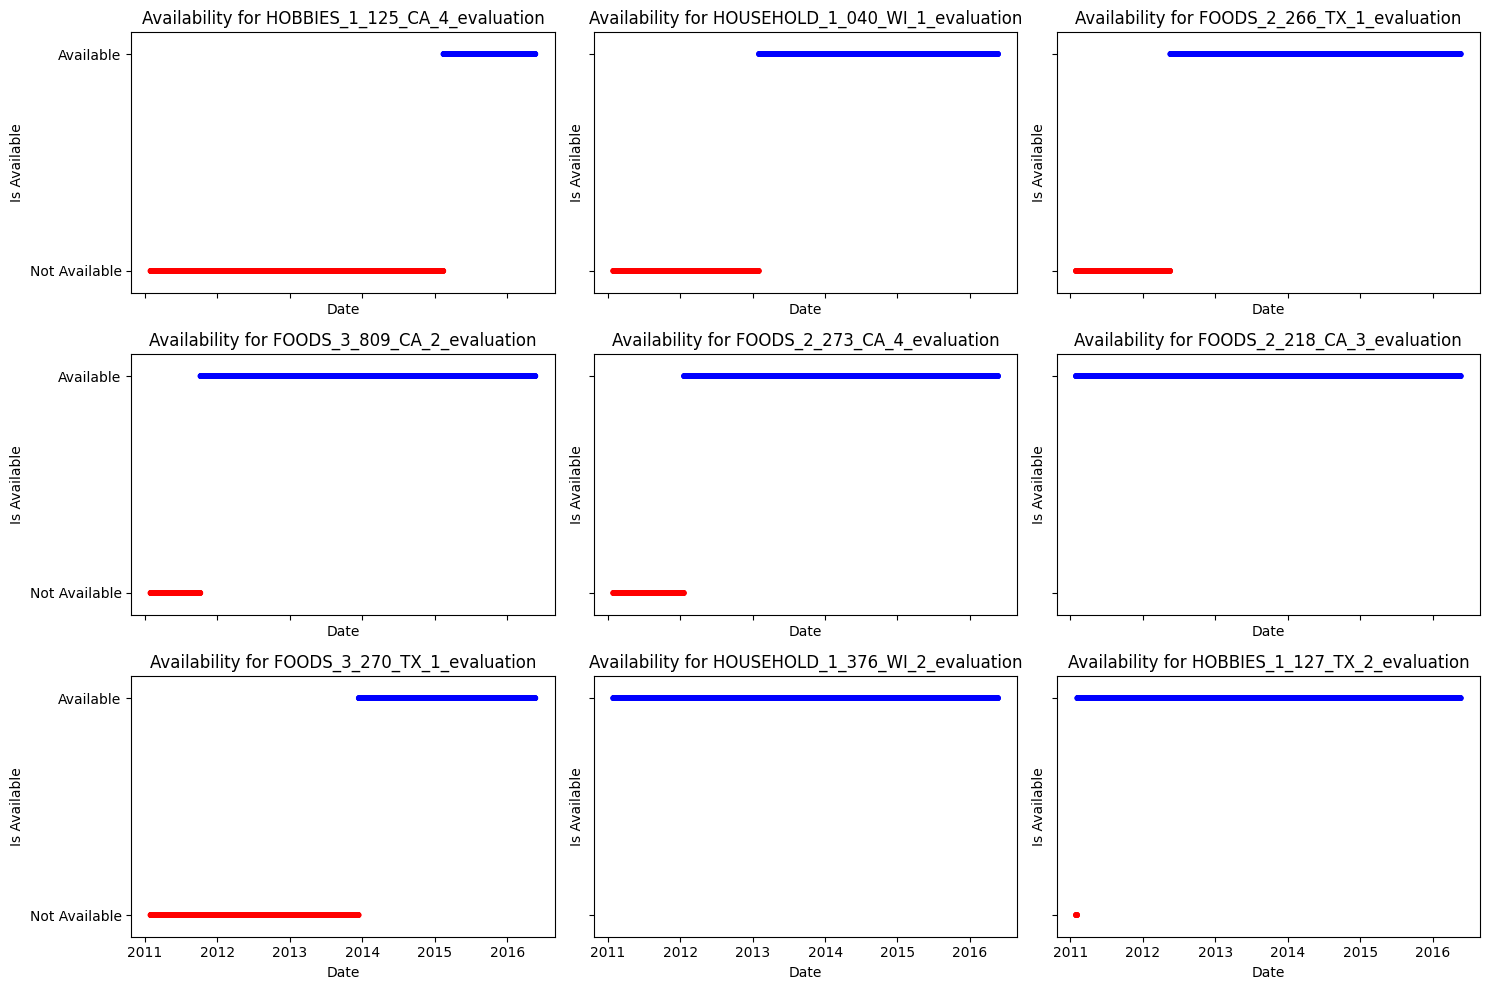

In [ ]:
# the avalablity state of a random unique_id for the entire time period
# show a grid of 3x3 subplots of random unique_id availability state over time
# within each plot, make not available state (0) red and available state (1) green

random_ids = m5_df['unique_id'].drop_duplicates().sample(9, random_state=40).values
fig, axs = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)
for i, unique_id in enumerate(random_ids):
    ax = axs[i // 3, i % 3]
    subset = m5_df[m5_df['unique_id'] == unique_id]
    ax.scatter(subset['ds'], subset['is_available'], c=subset['is_available'].map({0: 'red', 1: 'blue'}), s=10)
    ax.set_title(f'Availability for {unique_id}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Is Available')
    ax.set_ylim(-0.1, 1.1)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Not Available', 'Available'])
plt.tight_layout()
plt.show()



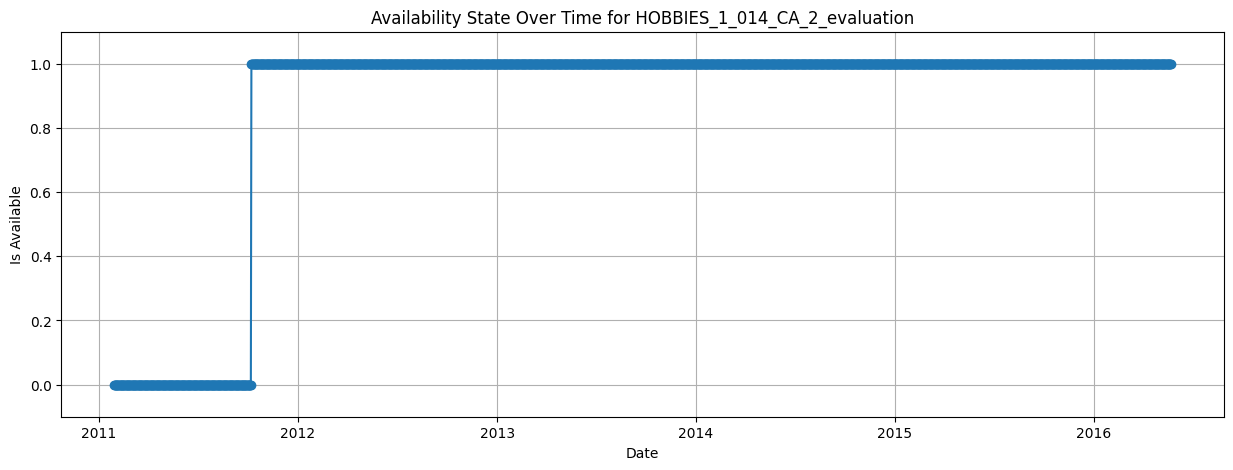

In [21]:
# the avalablity state of a random unique_id for the entire time period
random_unique_id = m5_df['unique_id'].sample(1).values[0]
unique_id_data = m5_df[m5_df['unique_id'] == random_unique_id]
plt.figure(figsize=(15, 5))
plt.plot(unique_id_data['ds'], unique_id_data['is_available'], marker='o')
plt.xlabel('Date')
plt.ylabel('Is Available')
plt.title(f'Availability State Over Time for {random_unique_id}')
plt.ylim(-0.1, 1.1)
plt.grid(True)
plt.show()
# m5_df

### Old code to be deleted

In [ ]:
# ==========================================
# 3. METRIC 2: WRMSSE (Item-Level Approximation)
# ==========================================
# Full WRMSSE aggregates 12 levels. We will compute Level 12 (Item-by-Store) WRMSSE.
print("\nComputing WRMSSE Weights (This is mathematically heavy)...")

# A. Calculate Scaling Factor (Denominator)
# S_i = RMSE of Naive Forecast on Training Data
# We need the training history for each item to compute this.
# This requires grouping the full training set (50M rows).
# APPROXIMATION: We will use the 'train_df' we loaded (last 2 years) for this scale.

# Sort train_df just in case
train_df = train_df.sort_values(['unique_id', 'ds'])

# Calculate diff squared for naive forecast (y_t - y_{t-1})^2
train_df['diff_sq'] = train_df.groupby('unique_id')['y'].diff().pow(2)
scaling_factors = train_df.groupby('unique_id')['diff_sq'].mean().pow(0.5)

# B. Calculate Dollar Weights
# Weight = Sum of (Sales * Price) in the last 28 days of Training
# We need to merge prices back to train_df if not present
# (In our previous script, train_df has 'sell_price')
last_28_days_train = train_df[train_df['ds'] >= (train_df['ds'].max() - pd.Timedelta(days=28))]
last_28_days_train['revenue'] = last_28_days_train['y'] * last_28_days_train['sell_price']
total_revenue = last_28_days_train['revenue'].sum()
item_revenue = last_28_days_train.groupby('unique_id')['revenue'].sum()
weights = item_revenue / total_revenue

# C. Calculate RMSSE for our Models
# RMSSE = RMSE / ScalingFactor
score_df = results_full.copy()
score_df['sq_err_nbeats'] = (score_df['y'] - score_df['NBEATSx'])**2
score_df['sq_err_lgbm'] = (score_df['y'] - score_df['lgbm_pred'])**2

# MSE per item
mse_nbeats = score_df.groupby('unique_id')['sq_err_nbeats'].mean()
mse_lgbm = score_df.groupby('unique_id')['sq_err_lgbm'].mean()

# RMSE per item
rmse_nbeats_series = mse_nbeats.pow(0.5)
rmse_lgbm_series = mse_lgbm.pow(0.5)

# RMSSE (Scaled Error)
rmsse_nbeats = rmse_nbeats_series / scaling_factors
rmsse_lgbm = rmse_lgbm_series / scaling_factors

# D. Weighted RMSSE
wrmsse_nbeats = (rmsse_nbeats * weights).sum()
wrmsse_lgbm = (rmsse_lgbm * weights).sum()

print(f"\nWRMSSE (Item-Level):")
print(f"N-BEATSx:  {wrmsse_nbeats:.4f}")
print(f"LightGBM:  {wrmsse_lgbm:.4f}")

# **5. The Conflict**
- Visualize the leaderboard.
- __Observation:__ "LightGBM has a lower RMSE (2.19 vs 2.36). Does this mean Trees win? Not necessarily. RMSE penalizes spikes in high-volume items. We need to check if the models are actually useful for the *entire* inventory."